Simulated Sigma Statistics:
  Mean sigma:   0.1079
  Std sigma:    0.0302
  Min sigma:    0.0444
  Max sigma:    0.1646
  Median sigma: 0.1060


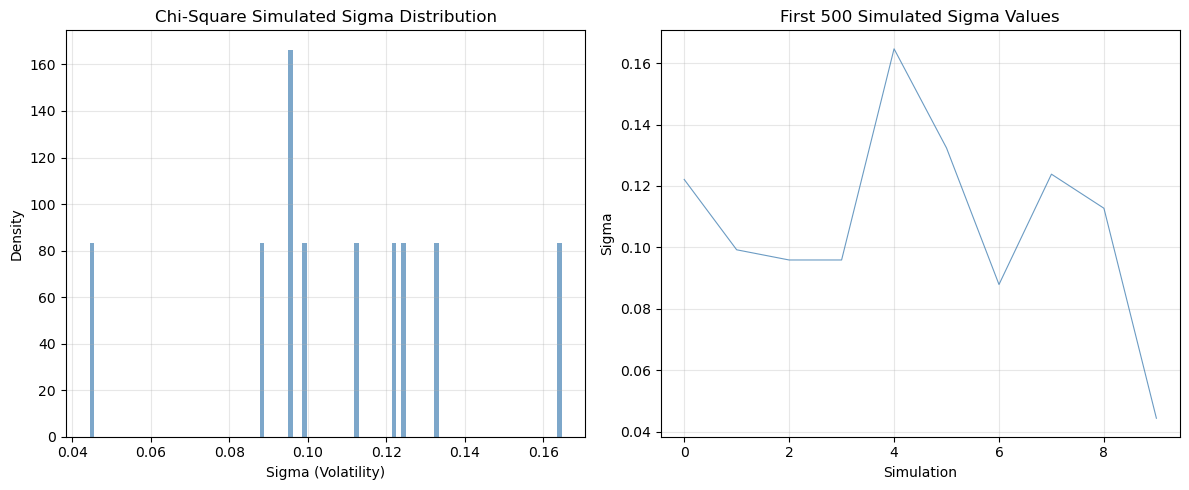

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_sigma_chisquare(n_simulations=10, df=5, scale=0.01, random_seed=42):
    """
    Simulate volatility (sigma) using a Chi-Square distribution.
    
    Parameters:
    -----------
    n_simulations : int    - number of simulations
    df            : int    - degrees of freedom (controls shape)
    scale         : float  - scaling factor to bring sigma to realistic range
    random_seed   : int    - for reproducibility
    """
    np.random.seed(random_seed)
    
    # Simulate chi-square values and scale them to realistic sigma range
    chi2_samples = np.random.chisquare(df=df, size=n_simulations)
    sigma_samples = np.sqrt(chi2_samples) * scale  # Take sqrt to get sigma from variance
    
    print(f"Simulated Sigma Statistics:")
    print(f"  Mean sigma:   {sigma_samples.mean():.4f}")
    print(f"  Std sigma:    {sigma_samples.std():.4f}")
    print(f"  Min sigma:    {sigma_samples.min():.4f}")
    print(f"  Max sigma:    {sigma_samples.max():.4f}")
    print(f"  Median sigma: {np.median(sigma_samples):.4f}")
    
    return sigma_samples


# Run simulation
sigma_samples = simulate_sigma_chisquare(
    n_simulations=10,
    df=5,       # Degrees of freedom — increase for higher average sigma
    scale=0.05  # Scale factor — adjust to match realistic volatility range
)

# Plot distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(sigma_samples, bins=100, density=True, alpha=0.7, color='steelblue')
plt.xlabel('Sigma (Volatility)')
plt.ylabel('Density')
plt.title('Chi-Square Simulated Sigma Distribution')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(sigma_samples[:500], linewidth=0.8, alpha=0.8, color='steelblue')
plt.xlabel('Simulation')
plt.ylabel('Sigma')
plt.title('First 500 Simulated Sigma Values')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()